In [28]:
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.metrics import (  # Метрики оценки качества модели
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
    mean_squared_error,
    root_mean_squared_error,
    mean_absolute_error,
    r2_score,
    mean_absolute_percentage_error
)
import matplotlib.pyplot as plt

# классификация

In [ ]:
df_titanic = sns.load_dataset('titanic')

In [ ]:
df_titanic.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [ ]:
df_titanic.select_dtypes(include='number').columns

Index(['survived', 'pclass', 'age', 'sibsp', 'parch', 'fare'], dtype='object')

In [ ]:
df_titanic['survived'].mean()

np.float64(0.3838383838383838)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(df_titanic[['age', 'sibsp', 'parch', 'fare']],
                                                    df_titanic['survived'],
                                                    train_size=0.7,
                                                    stratify=df_titanic['survived'],
                                                    random_state=1234
                                                    )

In [ ]:
X_train

,age,sibsp,parch,fare
477,29.0,1,0,7.0458
60,22.0,0,0,7.2292
508,28.0,0,0,22.5250
799,30.0,1,1,24.1500
251,29.0,1,1,10.4625
...,...,...,...,...
789,46.0,0,0,79.2000
718,NaN,0,0,15.5000
872,33.0,0,0,5.0000
390,36.0,1,2,120.0000


In [ ]:
X_test

,age,sibsp,parch,fare
132,47.0,1,0,14.5000
409,NaN,3,1,25.4667
247,24.0,0,2,14.5000
158,NaN,0,0,8.6625
791,16.0,0,0,26.0000
...,...,...,...,...
505,18.0,1,0,108.9000
829,62.0,0,0,80.0000
671,31.0,1,0,52.0000
5,NaN,0,0,8.4583


In [ ]:
y_train.mean(), y_test.mean()

(np.float64(0.38362760834670945), np.float64(0.3843283582089552))

In [ ]:
X_train.isna().sum()

,0
age,130
sibsp,0
parch,0
fare,0


In [ ]:
age_mean = X_train['age'].mean()
age_mean

np.float64(29.629999999999995)

In [ ]:
X_train['age'] = X_train['age'].fillna(age_mean)

In [ ]:
X_test['age'] = X_test['age'].fillna(age_mean)

In [ ]:
# ?LogisticRegression

In [ ]:
lg_model = LogisticRegression(random_state=1234)

In [ ]:
lg_model.fit(X_train, y_train)

LogisticRegression(random_state=1234)

In [ ]:
pred_test = lg_model.predict(X_test)
pred_train = lg_model.predict(X_train)

In [ ]:
# lg_model.predict_proba(X_test)

In [ ]:
proba_1_test = lg_model.predict_proba(X_test)[:,1]
proba_1_test[:5]

array([0.2180022 , 0.22825874, 0.39512306, 0.31552766, 0.45287855])

In [ ]:
proba_1_train = lg_model.predict_proba(X_train)[:,1]
proba_1_train[:5]

array([0.25627884, 0.3423941 , 0.38072877, 0.33114814, 0.28158667])

In [ ]:
X_train['pred'] = proba_1_train

In [ ]:
X_train

,age,sibsp,parch,fare,pred
477,29.00,1,0,7.0458,0.256279
60,22.00,0,0,7.2292,0.342394
508,28.00,0,0,22.5250,0.380729
799,30.00,1,1,24.1500,0.331148
251,29.00,1,1,10.4625,0.281587
...,...,...,...,...,...
789,46.00,0,0,79.2000,0.552687
718,29.63,0,0,15.5000,0.343441
872,33.00,0,0,5.0000,0.287493
390,36.00,1,2,120.0000,0.734586


In [ ]:
precision_test = precision_score(y_test, pred_test)
precision_train = precision_score(y_train, pred_train)
precision_test, precision_train

(0.6470588235294118, 0.8045977011494253)

In [ ]:
recall_score_test = recall_score(y_test, pred_test)
recall_score_train = recall_score(y_train, pred_train)
recall_score_test, recall_score_train

(0.21359223300970873, 0.2928870292887029)

In [ ]:
roc_auc_test = roc_auc_score(y_test, proba_1_test)
roc_auc_train = roc_auc_score(y_train, proba_1_train)
roc_auc_test, roc_auc_train

(np.float64(0.6952633127390409), np.float64(0.7224764644351465))

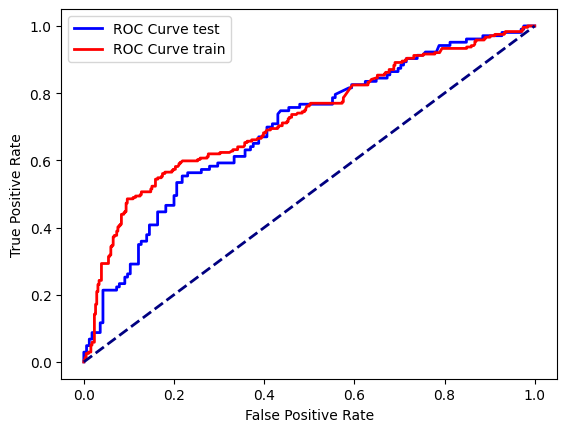

In [ ]:
fpr_test, tpr_test, _ = roc_curve(y_test, proba_1_test)
fpr_train, tpr_train, _ = roc_curve(y_train, proba_1_train)

plt.figure()
plt.plot(fpr_test, tpr_test, color='blue', lw=2, label='ROC Curve test')
plt.plot(fpr_train, tpr_train, color='red', lw=2, label='ROC Curve train')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
# plt.title(f'ROC Curve ({type(model).__name__})')
plt.legend()
plt.show()

<font color='red' size=10> !!! так делать нельзя

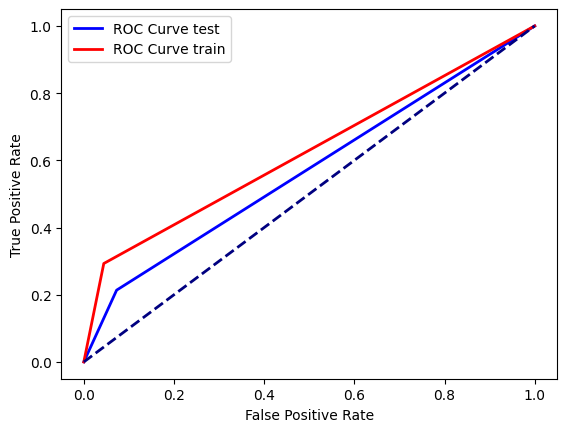

In [ ]:
fpr_test, tpr_test, _ = roc_curve(y_test, pred_test)
fpr_train, tpr_train, _ = roc_curve(y_train, pred_train)

plt.figure()
plt.plot(fpr_test, tpr_test, color='blue', lw=2, label='ROC Curve test')
plt.plot(fpr_train, tpr_train, color='red', lw=2, label='ROC Curve train')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
# plt.title(f'ROC Curve ({type(model).__name__})')
plt.legend()
plt.show()

# регрессия

In [3]:
df_mpg = sns.load_dataset('mpg')

In [5]:
df_mpg.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
0,18.0,8,307.0,130.0,3504,12.0,70,usa,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,usa,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,usa,plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,usa,amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,usa,ford torino


In [8]:
df_mpg.columns

Index(['mpg', 'cylinders', 'displacement', 'horsepower', 'weight',
       'acceleration', 'model_year', 'origin', 'name'],
      dtype='object')

In [9]:
# роли переменных
features = ['cylinders', 'displacement', 'horsepower', 'weight',
            'acceleration', 'model_year',]
target = 'mpg'

<Axes: xlabel='mpg', ylabel='Count'>

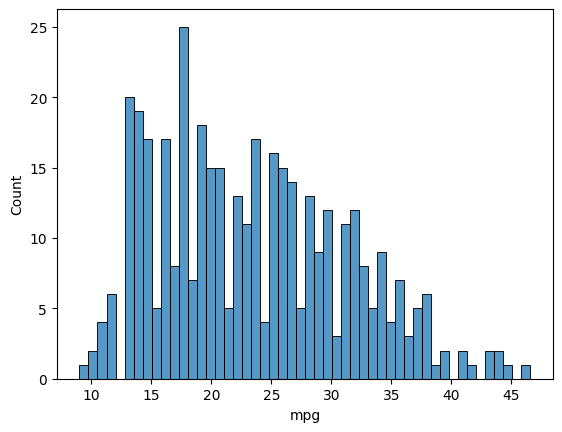

In [10]:
sns.histplot(df_mpg[target], bins=50)

In [7]:
df_mpg.isna().sum()

,0
mpg,0
cylinders,0
displacement,0
horsepower,6
weight,0
acceleration,0
model_year,0
origin,0
name,0


In [11]:
df_mpg[features].describe()

,cylinders,displacement,horsepower,weight,acceleration,model_year
count,398.000000,398.000000,392.000000,398.000000,398.000000,398.000000
mean,5.454774,193.425879,104.469388,2970.424623,15.568090,76.010050
std,1.701004,104.269838,38.491160,846.841774,2.757689,3.697627
min,3.000000,68.000000,46.000000,1613.000000,8.000000,70.000000
25%,4.000000,104.250000,75.000000,2223.750000,13.825000,73.000000
50%,4.000000,148.500000,93.500000,2803.500000,15.500000,76.000000
75%,8.000000,262.000000,126.000000,3608.000000,17.175000,79.000000
max,8.000000,455.000000,230.000000,5140.000000,24.800000,82.000000


<Axes: xlabel='horsepower', ylabel='Count'>

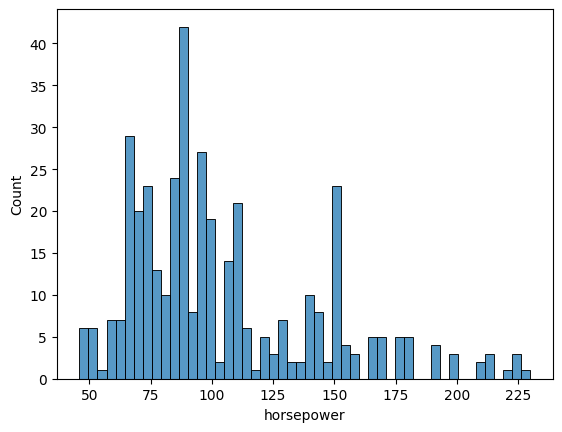

In [12]:
sns.histplot(df_mpg['horsepower'], bins=50)

In [13]:
X_train, X_test, y_train, y_test = train_test_split(df_mpg[features],
                                                    df_mpg[target],
                                                    train_size=0.8,
                                                    random_state=42)

In [14]:
X_train.shape, X_test.shape

((318, 6), (80, 6))

In [15]:
# обработка пропусков - средним
mean_horsepower = X_train['horsepower'].mean()
mean_horsepower

np.float64(103.28434504792332)

In [16]:
X_train['horsepower'] = X_train['horsepower'].fillna(mean_horsepower)
X_test['horsepower'] = X_test['horsepower'].fillna(mean_horsepower)

In [17]:
X_train.isna().sum()

,0
cylinders,0
displacement,0
horsepower,0
weight,0
acceleration,0
model_year,0


In [18]:
X_test.isna().sum()

,0
cylinders,0
displacement,0
horsepower,0
weight,0
acceleration,0
model_year,0


In [21]:
# ?LinearRegression

In [22]:
# строим модель
lin_model = LinearRegression()

In [23]:
lin_model

LinearRegression()

In [25]:
lin_model.fit(X_train, y_train)

LinearRegression()

In [26]:
y_pred_test = lin_model.predict(X_test)
y_pred_test

array([31.53100066, 30.70876514, 21.76194314, 17.00377193, 12.61302683,
       26.21324367, 28.91129096,  9.20353629, 17.21953655, 22.74579566,
       12.68145245, 34.98791907, 26.69337402, 14.05843137, 24.77707145,
        5.90336575, 30.87257713, 23.81305083, 15.8809813 , 35.16334867,
       23.44499336, 19.69075296, 29.32876149, 30.33499375, 15.09755805,
       34.56195408, 25.77986672, 25.76025003, 22.17162712,  7.92223327,
       29.35882156, 34.94825054, 20.00737857, 24.92520638, 33.1036795 ,
       12.27810205, 24.47979548, 22.19736856, 12.3777133 , 26.96553906,
       27.64478739, 27.40746464, 20.293365  ,  7.75549155, 23.25676937,
       33.67984388, 26.58254279, 24.46995197, 22.78524086, 27.69247695,
       23.46862653, 32.51635882, 31.29683966, 10.59238332, 29.03332523,
        9.3740976 , 19.45918353, 28.30605391, 24.25241398, 20.7456282 ,
       16.5022124 , 30.73781665, 24.91738512, 20.29855644, 21.63436242,
       24.35614585, 25.87136015, 33.72519524, 29.33932962, 12.67

In [27]:
y_pred_train = lin_model.predict(X_train)
y_pred_train

array([15.64786536, 24.23975779, 34.82407019, 33.03754192, 24.3629907 ,
       10.77148207, 31.931723  , 31.7262754 , 25.95398025,  7.65090093,
       15.2572596 , 29.97018757, 26.52088767, 32.21131685, 23.7829104 ,
       33.84896304, 31.24303271, 24.10109769, 27.66845619, 12.8984145 ,
       32.90552708, 25.08436466, 20.11330632, 15.52747608, 19.44067654,
        9.57841815, 26.68049429, 10.21302211, 32.58053946, 34.45289348,
       29.92862276, 26.78575934, 21.75844589, 35.04388446, 27.70494439,
       24.35950746, 25.65242552, 23.36382842, 31.40417542, 22.1100031 ,
       12.78400285, 25.16024616, 21.43839235, 24.05211784, 20.94114477,
       27.80966632, 34.1286354 , 28.39701988, 34.06486185, 29.79937909,
       33.64568063, 28.60123292, 32.68520447, 21.19624361, 23.45659525,
       20.86826385, 22.24394341, 35.68257125, 30.53666891, 32.46170605,
       17.25444034, 10.65725677, 18.72381497, 21.74864526, 22.93254486,
       30.21249279, 25.59467289, 26.49836151, 28.79350718, 25.58

In [33]:
def get_metrics(y_pred, y_fact):
  mse = mean_squared_error(y_fact, y_pred)
  # rmse = mse**(1/2)
  rmse = root_mean_squared_error(y_fact, y_pred)
  mae = mean_absolute_error(y_fact, y_pred)
  r2 = r2_score(y_fact, y_pred)
  mape = mean_absolute_percentage_error(y_fact, y_pred)
  return {'mse':mse, 'rmse':rmse, 'mae':mae, 'mape':mape, 'r2':r2}

In [44]:
?sns.histplot

In [47]:
def get_res(y_pred, y_fact):
  res = y_fact - y_pred
  sns.histplot(res, bins=50)
  plt.title('y_fact - y_pred')
  plt.show()

In [34]:
metrics_train = get_metrics(y_pred_train, y_train)
metrics_test = get_metrics(y_pred_test, y_test)

In [35]:
metrics_train

{'mse': 12.294936039233074,
 'rmse': 3.5064135579296796,
 'mae': 2.6967448334030055,
 'mape': 0.12398926552153604,
 'r2': 0.803896701317778}

In [36]:
metrics_test

{'mse': 9.440915081847931,
 'rmse': 3.0726072124252934,
 'mae': 2.467213516613638,
 'mape': 0.12414683764128401,
 'r2': 0.8244087869053469}

> в целом можно считать модель непереобученной

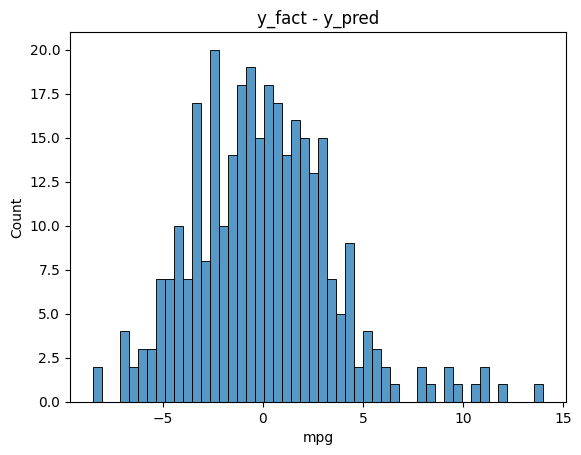

In [48]:
get_res(y_pred_train, y_train)

In [50]:
y_pred_train.mean()

np.float64(23.608176100628924)

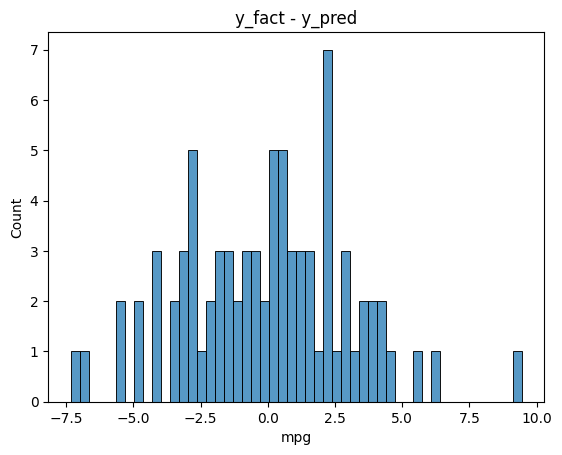

In [49]:
get_res(y_pred_test, y_test)

- пропуски - 5
- выбросы - 3
- отбор переменных - 3
- модели - 5

In [51]:
5*3*3*5

225